# Analisis 5W+1H - Chicago Crime (Part 2: WHO)

Bagian ini berfokus pada **WHO (Siapa)**, mengeksplorasi profil kejahatan dari sisi pelaku maupun sifat kejahatannya, seperti tingkat penangkapan (Arrest Rate) dan kekerasan domestik (Domestic Violence).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency
import warnings, os

warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 150
plt.rcParams['font.size'] = 10
sns.set_style('whitegrid')

# Pastikan direktori output ada
OUT = r'c:\Python\Data_Mining\output_5w1h'
os.makedirs(OUT, exist_ok=True)

print("Setup selesai.")

Setup selesai.


In [2]:
# Load data (Fallback ke CSV jika pickle dari proses sebelumnya belum ada)
pickle_path = f'{OUT}/_temp_df.pkl'

if os.path.exists(pickle_path):
    df = pd.read_pickle(pickle_path)
    print(f"Data berhasil dimuat dari pickle: {len(df):,} baris.")
else:
    print("File pickle tidak ditemukan. Memuat dari Mining.csv dan melakukan preprocessing...")
    cols = ['Date','Primary Type','Description','Location Description',
            'Arrest','Domestic','District','Ward','Community Area',
            'Year','Latitude','Longitude','Beat','IUCR','FBI Code','Block']
    df = pd.read_csv(r'c:\Python\Data_Mining\Mining.csv', usecols=cols, nrows=500000, low_memory=False)
    df = df.sample(n=300000, random_state=42).reset_index(drop=True)

    # Feature Engineering yang diperlukan untuk seluruh analisis 5W1H
    df['Date'] = pd.to_datetime(df['Date'], format='mixed', errors='coerce')
    df['Hour'] = df['Date'].dt.hour
    df['DayOfWeek'] = df['Date'].dt.dayofweek
    df['Month'] = df['Date'].dt.month

    season_map = {12:'Winter',1:'Winter',2:'Winter',
                  3:'Spring',4:'Spring',5:'Spring',
                  6:'Summer',7:'Summer',8:'Summer',
                  9:'Fall',10:'Fall',11:'Fall'}
    df['Season'] = df['Month'].map(season_map)
    df['IsNight'] = df['Hour'].apply(lambda x: 1 if (x >= 22 or x < 6) else 0)
    df['IsWeekend'] = df['DayOfWeek'].apply(lambda x: 1 if x >= 5 else 0)

    severity_map = {'01A':'Kritis','01B':'Kritis',
        '02':'Tinggi','04A':'Tinggi','04B':'Tinggi','03':'Tinggi','15':'Tinggi',
        '05':'Sedang','06':'Sedang','07':'Sedang','09':'Sedang','08A':'Sedang','08B':'Sedang',
        '10':'Rendah','11':'Rendah','14':'Rendah','16':'Rendah','17':'Rendah',
        '18':'Rendah','19':'Rendah','20':'Rendah','22':'Rendah','24':'Rendah','26':'Rendah'}
    df['CrimeSeverity'] = df['FBI Code'].map(severity_map).fillna('Rendah')

    df.to_pickle(pickle_path)
    print(f"Pre-processing selesai. Data disimpan ke pickle. Sample: {len(df):,} rows.")

Data berhasil dimuat dari pickle: 300,000 baris.


---
## OPSI 2: WHO - Siapa yang Terlibat?
---


[2.1] Arrest Rate Global: 26.55%
      Domestic Rate      : 15.70%


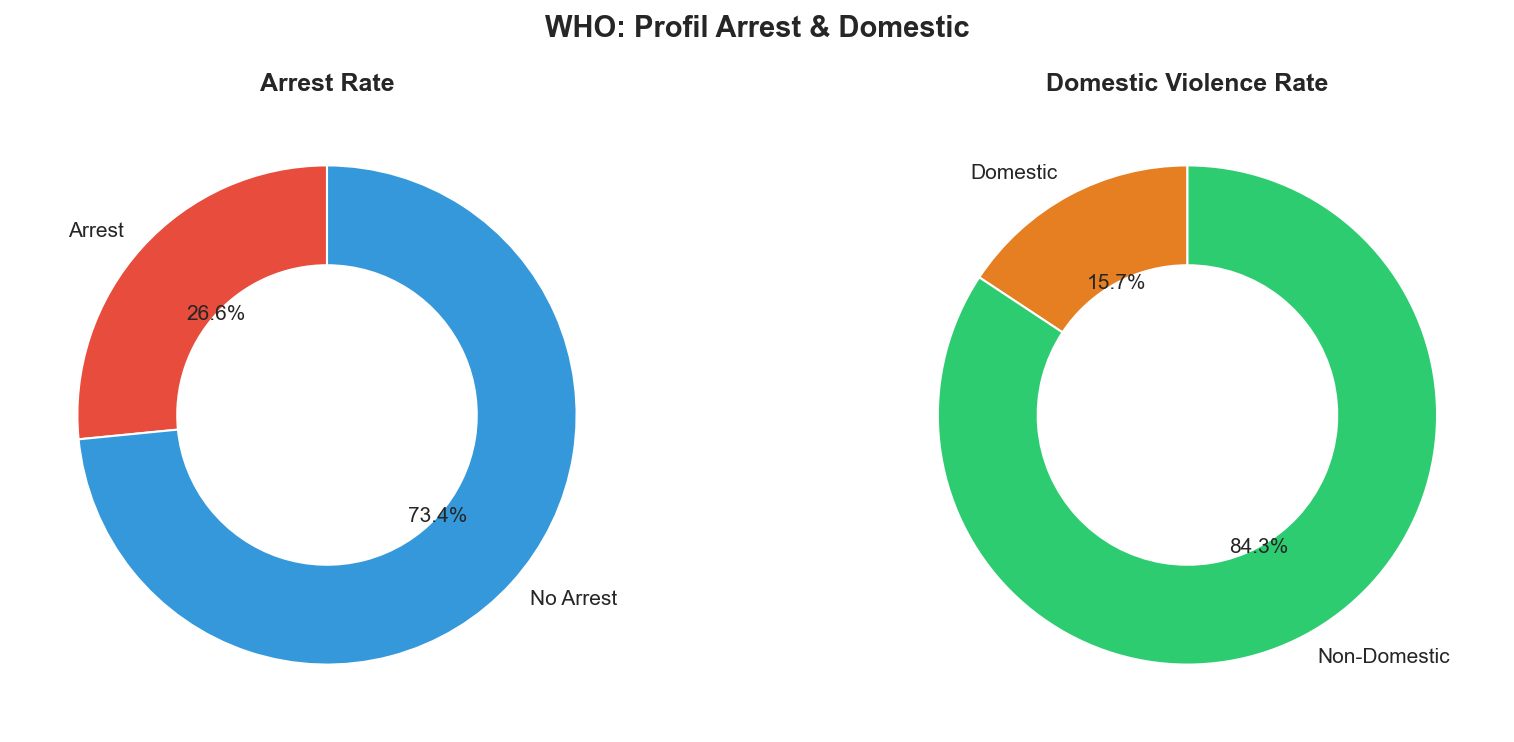

In [3]:
arrest_pct = df['Arrest'].mean() * 100
domestic_pct = df['Domestic'].mean() * 100
print(f"\n[2.1] Arrest Rate Global: {arrest_pct:.2f}%")
print(f"      Domestic Rate      : {domestic_pct:.2f}%")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].pie([arrest_pct, 100-arrest_pct], labels=['Arrest','No Arrest'],
            autopct='%1.1f%%', colors=['#e74c3c','#3498db'], startangle=90,
            wedgeprops=dict(width=0.4))
axes[0].set_title('Arrest Rate', fontsize=12, fontweight='bold')
axes[1].pie([domestic_pct, 100-domestic_pct], labels=['Domestic','Non-Domestic'],
            autopct='%1.1f%%', colors=['#e67e22','#2ecc71'], startangle=90,
            wedgeprops=dict(width=0.4))
axes[1].set_title('Domestic Violence Rate', fontsize=12, fontweight='bold')
plt.suptitle('WHO: Profil Arrest & Domestic', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUT}/who_01_arrest_rate.png', bbox_inches='tight')
plt.show()


[2.2] Arrest Rate per Crime Type:
                                   Total  Arrested        Rate
Primary Type                                                  
SEX OFFENSE                         1588       460   28.967254
OBSCENITY                             16         7   43.750000
HOMICIDE                            7922      3797   47.929816
PUBLIC PEACE VIOLATION               676       438   64.792899
CRIMINAL TRESPASS                   7608      5435   71.437960
WEAPONS VIOLATION                   3514      2512   71.485487
OTHER NARCOTIC VIOLATION               4         3   75.000000
INTERFERENCE WITH PUBLIC OFFICER     316       267   84.493671
CONCEALED CARRY LICENSE VIOLATION     47        43   91.489362
LIQUOR LAW VIOLATION                 896       894   99.776786
GAMBLING                             486       485   99.794239
NARCOTICS                          24709     24659   99.797645
PROSTITUTION                        2984      2978   99.798928
PUBLIC INDECENCY    

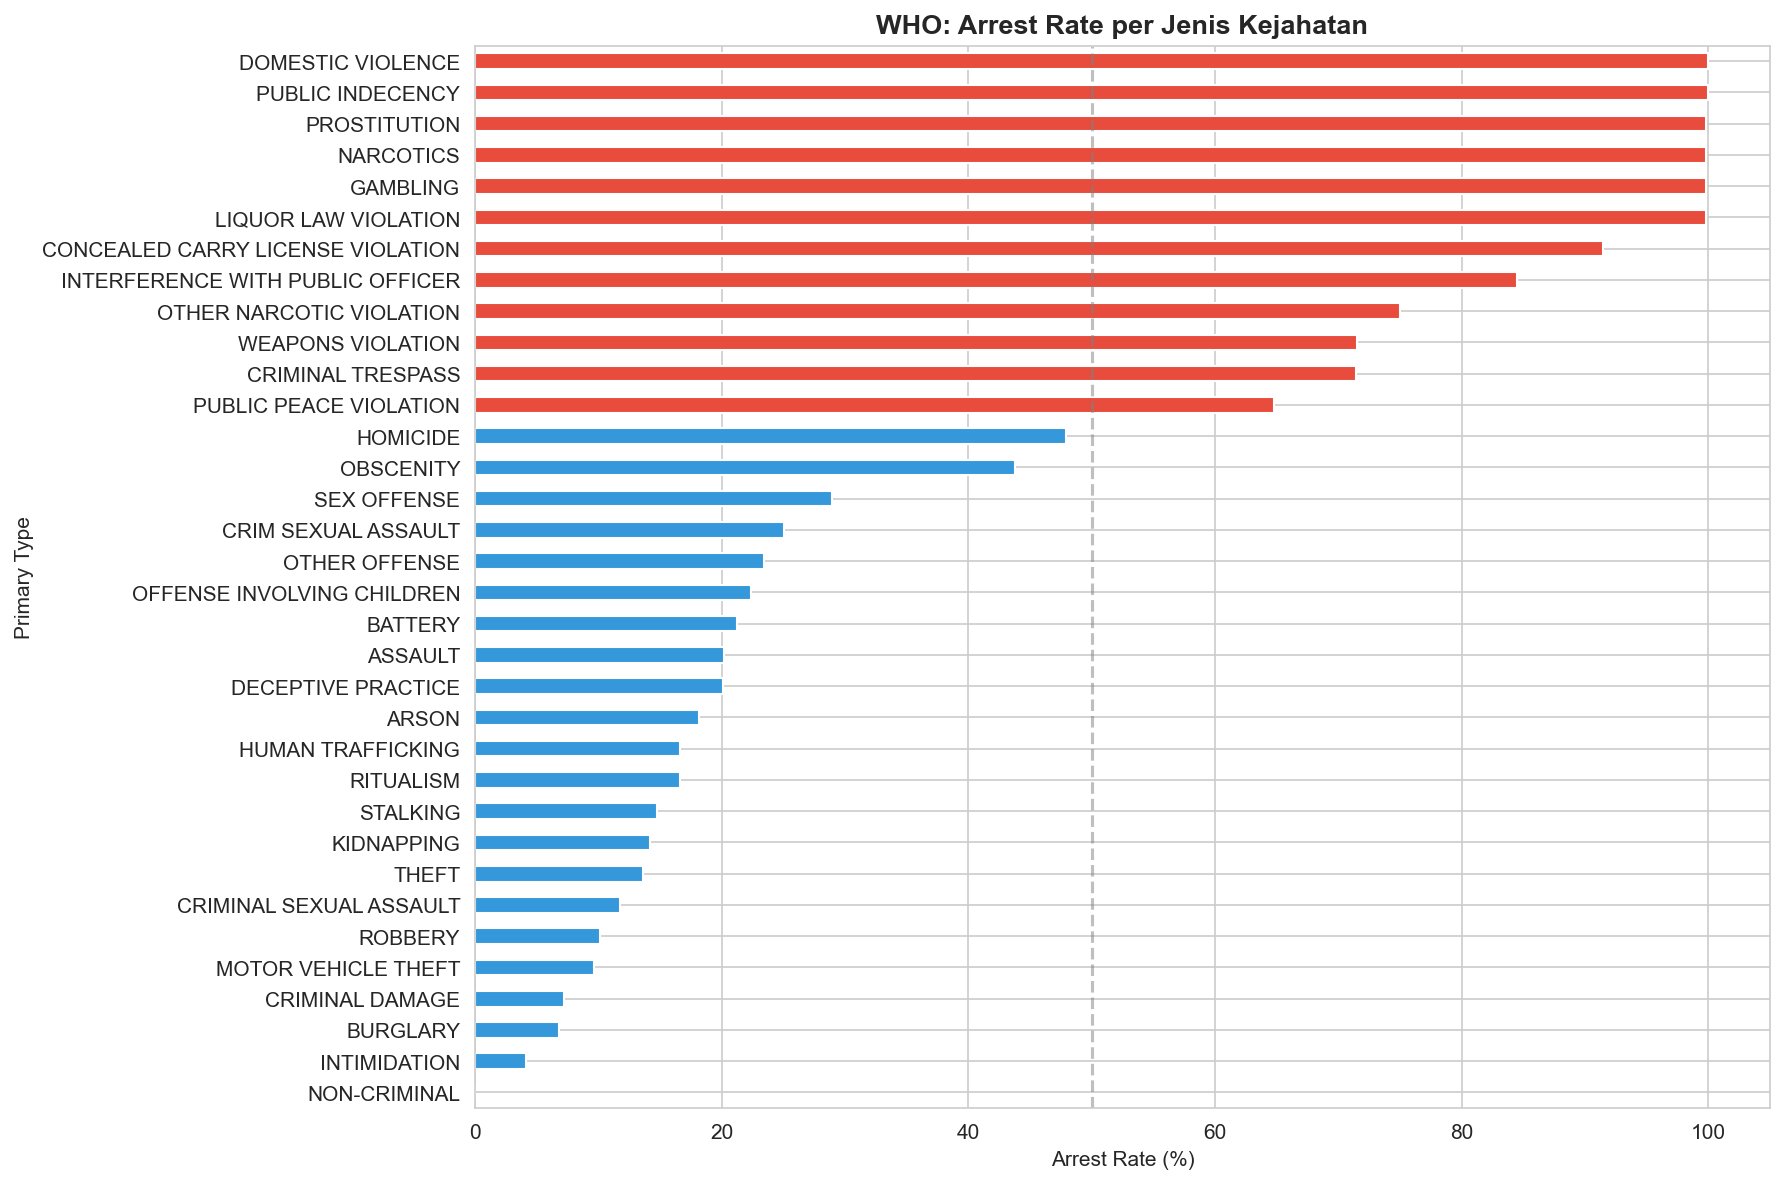

In [4]:
print("\n[2.2] Arrest Rate per Crime Type:")
ar_by_crime = df.groupby('Primary Type').agg(
    Total=('Arrest','count'), Arrested=('Arrest','sum')
).assign(Rate=lambda x: x['Arrested']/x['Total']*100)
ar_by_crime = ar_by_crime.sort_values('Rate', ascending=True)
print(ar_by_crime.tail(15).to_string())

fig, ax = plt.subplots(figsize=(12, 8))
colors = ['#e74c3c' if r > 50 else '#3498db' for r in ar_by_crime['Rate']]
ar_by_crime['Rate'].plot(kind='barh', ax=ax, color=colors)
ax.set_title('WHO: Arrest Rate per Jenis Kejahatan', fontsize=13, fontweight='bold')
ax.set_xlabel('Arrest Rate (%)')
ax.axvline(x=50, color='gray', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig(f'{OUT}/who_02_arrest_by_crime.png', bbox_inches='tight')
plt.show()


[2.3] Tren Arrest Rate Tahunan:
  2001: 29.4% (67,808/230,397)
  2002: 40.3% (530/1,316)
  2003: 45.3% (261/576)
  2004: 38.7% (222/574)
  2005: 39.4% (229/581)
  2006: 45.7% (216/473)
  2007: 42.5% (201/473)
  2008: 34.4% (212/616)
  2009: 36.3% (190/524)
  2010: 36.8% (146/397)
  2011: 32.9% (150/456)
  2012: 35.6% (168/472)
  2013: 33.4% (144/431)
  2014: 31.2% (158/507)
  2015: 35.6% (233/654)
  2016: 25.1% (195/777)
  2017: 23.6% (198/840)
  2018: 26.6% (210/788)
  2019: 23.1% (167/724)
  2020: 25.7% (284/1,105)
  2021: 25.7% (378/1,472)
  2022: 16.3% (452/2,769)
  2023: 12.7% (6,165/48,735)
  2024: 30.6% (169/553)
  2025: 15.2% (575/3,790)


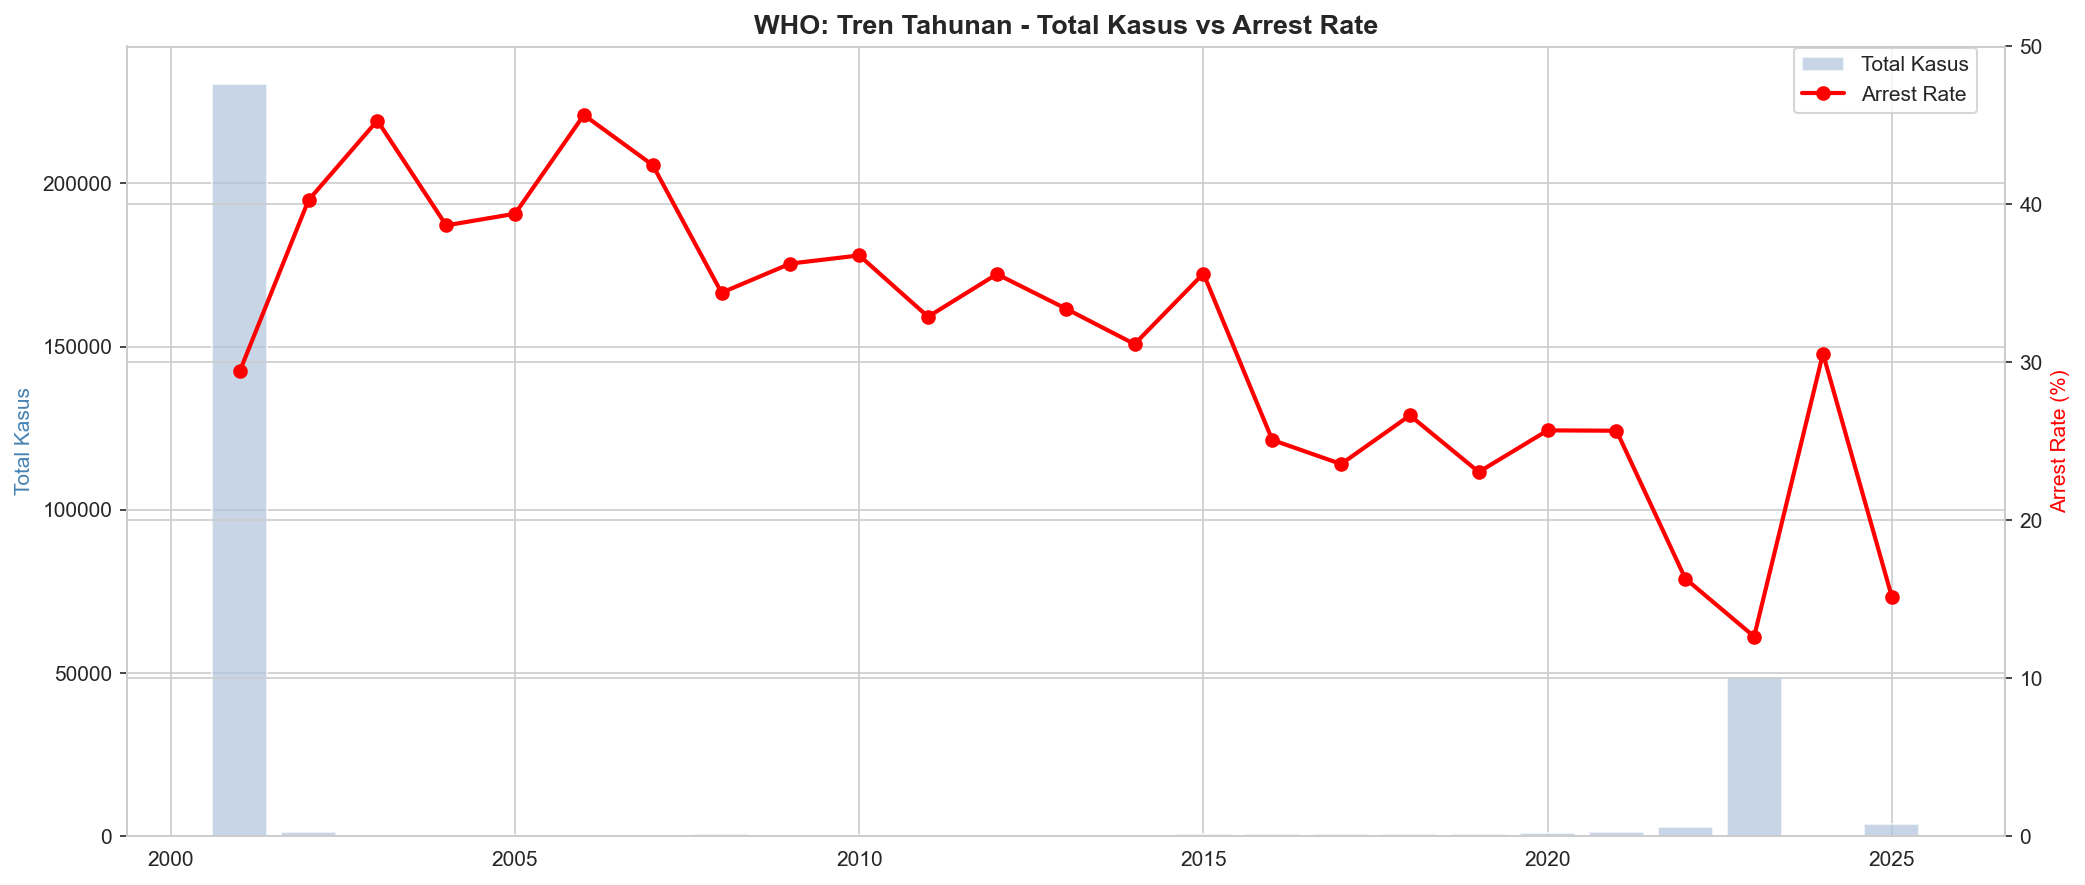

In [5]:
print("\n[2.3] Tren Arrest Rate Tahunan:")
yearly = df.groupby('Year').agg(Total=('Arrest','count'), Arrested=('Arrest','sum'))
yearly['Rate'] = yearly['Arrested'] / yearly['Total'] * 100
for y, row in yearly.iterrows():
    print(f"  {y}: {row['Rate']:.1f}% ({int(row['Arrested']):,}/{int(row['Total']):,})")

fig, ax1 = plt.subplots(figsize=(14, 6))
ax1.bar(yearly.index, yearly['Total'], color='lightsteelblue', alpha=0.7, label='Total Kasus')
ax1.set_ylabel('Total Kasus', color='steelblue')
ax2 = ax1.twinx()
ax2.plot(yearly.index, yearly['Rate'], 'ro-', linewidth=2, markersize=6, label='Arrest Rate')
ax2.set_ylabel('Arrest Rate (%)', color='red')
ax2.set_ylim(0, 50)
plt.title('WHO: Tren Tahunan - Total Kasus vs Arrest Rate', fontsize=13, fontweight='bold')
fig.legend(loc='upper right', bbox_to_anchor=(0.95, 0.95))
plt.tight_layout()
plt.savefig(f'{OUT}/who_03_arrest_trend.png', bbox_inches='tight')
plt.show()


[2.4] Domestic Violence Profile:
  Total Domestic Cases: 47,108
  Top Crime Types (Domestic):
    BATTERY: 27,319
    ASSAULT: 6,159
    OTHER OFFENSE: 4,455
    CRIMINAL DAMAGE: 3,540
    THEFT: 1,906


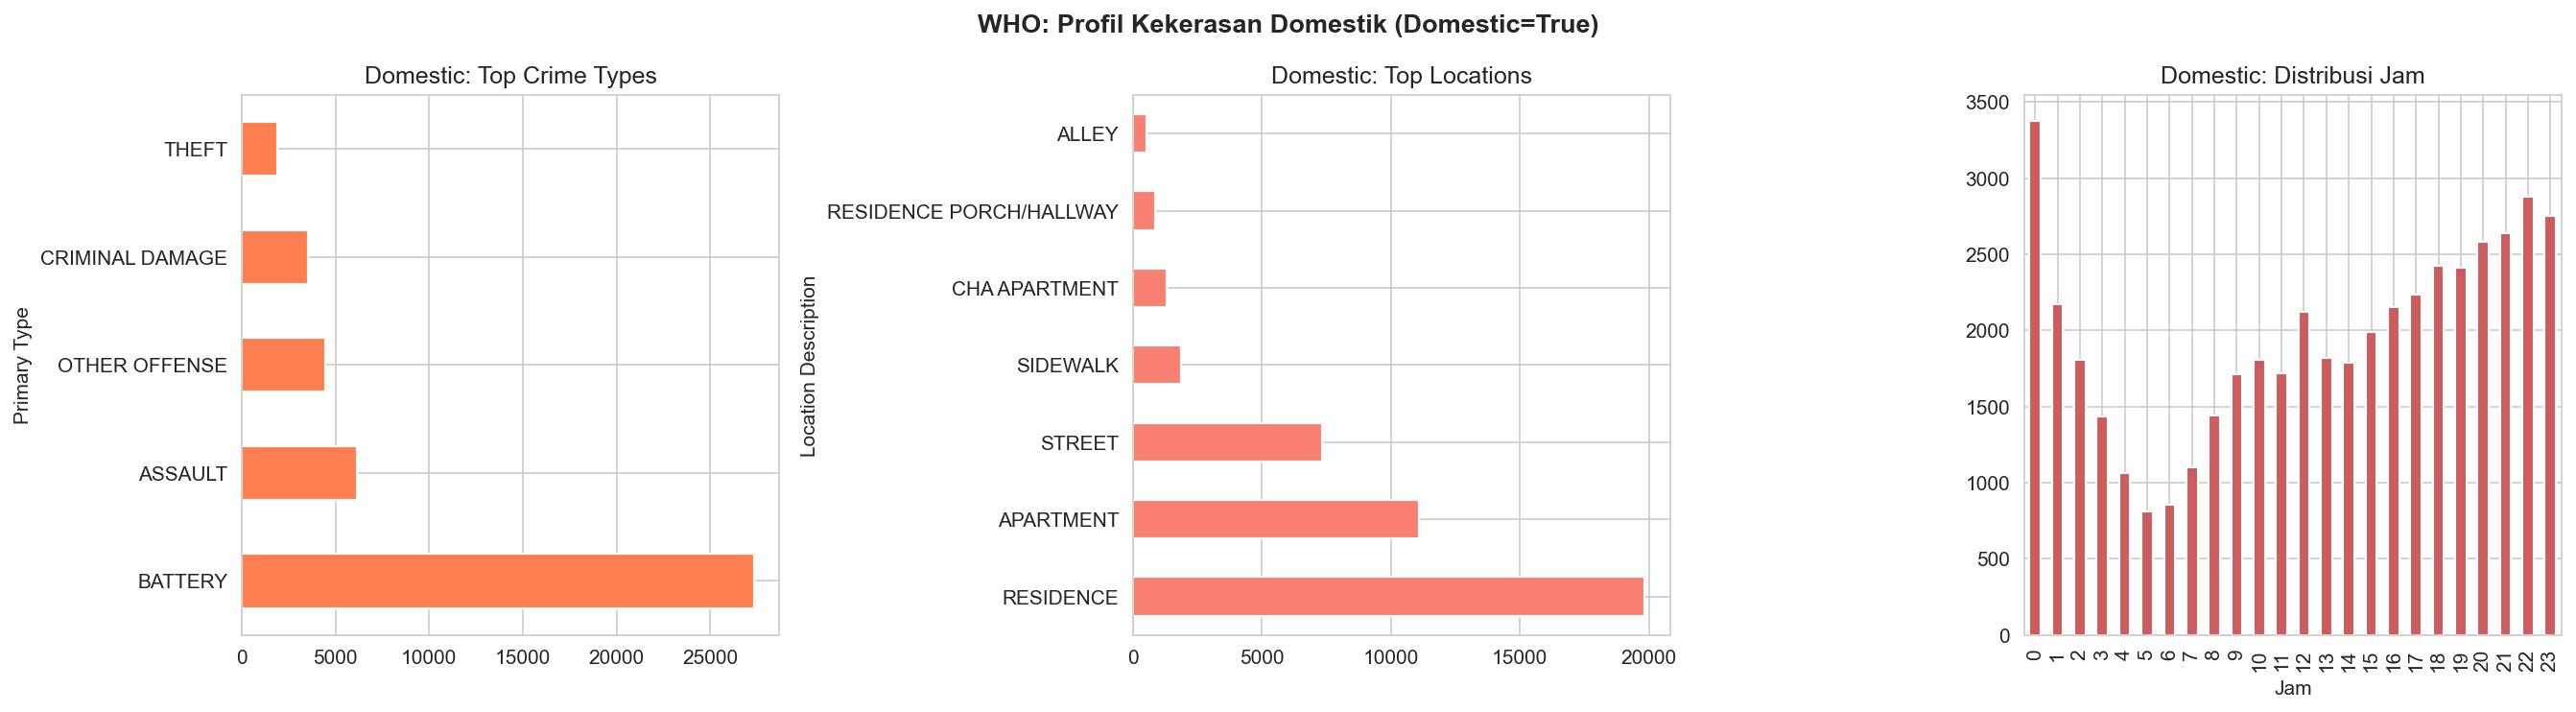

In [6]:
print("\n[2.4] Domestic Violence Profile:")
dom = df[df['Domestic']==True]
print(f"  Total Domestic Cases: {len(dom):,}")
print(f"  Top Crime Types (Domestic):")
dom_crimes = dom['Primary Type'].value_counts().head(5)
for c, n in dom_crimes.items():
    print(f"    {c}: {n:,}")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
dom_crimes.head(7).plot(kind='barh', ax=axes[0], color='coral')
axes[0].set_title('Domestic: Top Crime Types')
dom['Location Description'].value_counts().head(7).plot(kind='barh', ax=axes[1], color='salmon')
axes[1].set_title('Domestic: Top Locations')
dom['Hour'].value_counts().sort_index().plot(kind='bar', ax=axes[2], color='indianred')
axes[2].set_title('Domestic: Distribusi Jam')
axes[2].set_xlabel('Jam')
plt.suptitle('WHO: Profil Kekerasan Domestik (Domestic=True)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUT}/who_04_domestic_profile.png', bbox_inches='tight')
plt.show()

In [7]:
ct = pd.crosstab(df['Arrest'], df['Domestic'])
chi2, p, dof, expected = chi2_contingency(ct)
print(f"\n[2.5] Chi-Square Test: Arrest x Domestic")
print(f"  Chi2 = {chi2:.2f}, p-value = {p:.2e}, dof = {dof}")
print(f"  Kesimpulan: {'SIGNIFIKAN' if p < 0.05 else 'TIDAK SIGNIFIKAN'} (alpha=0.05)")
print(f"  Contingency Table:\n{ct}")


[2.5] Chi-Square Test: Arrest x Domestic
  Chi2 = 802.75, p-value = 1.36e-176, dof = 1
  Kesimpulan: SIGNIFIKAN (alpha=0.05)
  Contingency Table:
Domestic   False  True 
Arrest                 
False     183246  37093
True       69646  10015
